## 1. Configuração dos experimentos

In [1]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report
from sklearn.utils import resample
import matplotlib.pyplot as plt

## 2. Carregamento e preparação dos dados

In [2]:
treino = pd.read_csv('../../dataset/treino.csv')
teste = pd.read_csv('../../dataset/teste.csv')
validacao = pd.read_csv('../../dataset/validacao.csv')

treino = treino.replace({'b': 0, 'o': -1, 'x': 1})
teste = teste.replace({'b': 0, 'o': -1, 'x': 1})
validacao = validacao.replace({'b': 0, 'o': -1, 'x': 1})

In [3]:
print("Antes:\n", treino['classe'].value_counts())

empate = treino[treino['classe'] == 'Empate']
outras = treino[treino['classe'] != 'Empate']

alvo = treino['classe'].value_counts().max()

empate_up = resample(empate,
                     replace=True,
                     n_samples=alvo,
                     random_state=42)

treino_bal = pd.concat([outras, empate_up]).sample(frac=1, random_state=42)

print("Depois:\n", treino_bal['classe'].value_counts())

Antes:
 classe
Tem jogo    140
O venceu    140
X venceu    140
Empate       10
Name: count, dtype: int64
Depois:
 classe
Empate      140
O venceu    140
Tem jogo    140
X venceu    140
Name: count, dtype: int64


In [4]:
x_treino = treino_bal.drop(columns=['classe']).astype(int)
y_treino = treino_bal['classe']
x_teste = teste.drop(columns=['classe']).astype(int)
y_teste = teste['classe']
x_validacao = validacao.drop(columns=['classe']).astype(int)
y_validacao = validacao['classe']

## 3. Treinamento e validação do MLP

In [5]:
resultados = {}
modelos = {}
predicoes = {}

def avaliar(nome, modelo):
    modelo.fit(x_treino, y_treino)
    y_pred = modelo.predict(x_validacao)
    resultados[nome] = {
        'acuracia': accuracy_score(y_validacao, y_pred),
        'precisao': precision_score(y_validacao, y_pred, average='macro', zero_division=0),
        'recall':   recall_score(y_validacao, y_pred, average='macro', zero_division=0),
        'f1':       f1_score(y_validacao, y_pred, average='macro', zero_division=0),
    }
    modelos[nome] = modelo
    predicoes[nome] = y_pred
    return modelo, y_pred

In [6]:
avaliar('mlp_1',
        MLPClassifier(hidden_layer_sizes=(10,),
                   activation='relu',
                   solver='adam',
                   learning_rate_init=0.001,
                   momentum=0.1,
                   max_iter=3000,
                   random_state=42)
        )

(MLPClassifier(hidden_layer_sizes=(10,), max_iter=3000, momentum=0.1,
               random_state=42),
 array(['O venceu', 'Tem jogo', 'X venceu', 'O venceu', 'O venceu',
        'O venceu', 'Tem jogo', 'Tem jogo', 'X venceu', 'Tem jogo',
        'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu', 'Tem jogo',
        'O venceu', 'Tem jogo', 'X venceu', 'O venceu', 'X venceu',
        'X venceu', 'X venceu', 'Empate', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'O venceu', 'Tem jogo', 'Tem jogo',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'X venceu', 'O venceu',
        'X venceu', 'Tem jogo', 'X venceu', 'X venceu', 'Tem jogo',
        'X venceu', 'Tem jogo', 'Tem jogo', 'X venceu', 'X venceu',
        'Tem jo

In [7]:
avaliar('mlp_2',
        MLPClassifier(hidden_layer_sizes=(16,),
                   activation='relu',
                   solver='adam',
                   learning_rate_init=0.001,
                   momentum=0.1,
                   max_iter=3000,
                   random_state=42)
        )

(MLPClassifier(hidden_layer_sizes=(16,), max_iter=3000, momentum=0.1,
               random_state=42),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'O venceu', 'Tem jogo', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'Tem jogo',
        'Tem jogo', 'X venceu', 'X venceu', 'Tem jogo', 'Tem jogo',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'O venceu', 'X venceu', 'O venceu', 'X venceu', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu',
        'X venceu', 'Empate', 'X venceu', 'Tem jogo', 'Tem jogo',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'X venceu',
        'X venceu', 'X venceu', 'Tem jogo', 'Empate', 'X venceu',
        'O venceu

In [8]:
avaliar('mlp_3',
        MLPClassifier(hidden_layer_sizes=(32,),
                   activation='relu',
                   solver='adam',
                   learning_rate_init=0.001,
                   momentum=0.1,
                   max_iter=3000,
                   random_state=42)
        )

(MLPClassifier(hidden_layer_sizes=(32,), max_iter=3000, momentum=0.1,
               random_state=42),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'Tem jogo', 'Tem jogo', 'X venceu', 'X venceu',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'Tem jogo',
        'O venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'X venceu', 'Tem jogo',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'X venceu', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Empate', 'X venceu', 'Tem jogo',
        'Tem jogo

In [9]:
avaliar('mlp_4',
        MLPClassifier(hidden_layer_sizes=(64,),
                   activation='relu',
                   solver='adam',
                   learning_rate_init=0.001,
                   momentum=0.1,
                   max_iter=3000,
                   random_state=42)
        )

(MLPClassifier(hidden_layer_sizes=(64,), max_iter=3000, momentum=0.1,
               random_state=42),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'Tem jogo', 'Tem jogo', 'X venceu', 'X venceu',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'Tem jogo',
        'Tem jogo', 'X venceu', 'Tem jogo', 'Tem jogo', 'Tem jogo',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'Tem jogo', 'O venceu', 'X venceu', 'Tem jogo',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'X venceu', 'Empate', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'O venc

In [10]:
avaliar('mlp_5',
        MLPClassifier(hidden_layer_sizes=(32,16),
                   activation='relu',
                   solver='adam',
                   learning_rate_init=0.001,
                   momentum=0.1,
                   max_iter=3000,
                   random_state=42)
        )

(MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=3000, momentum=0.1,
               random_state=42),
 array(['O venceu', 'Tem jogo', 'X venceu', 'Tem jogo', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'O venceu', 'O venceu', 'Tem jogo',
        'O venceu', 'X venceu', 'X venceu', 'Tem jogo', 'X venceu',
        'X venceu', 'X venceu', 'Tem jogo', 'Tem jogo', 'X venceu',
        'X venceu', 'Tem jogo', 'O venceu', 'O venceu', 'O venceu',
        'O venceu', 'O venceu', 'Tem jogo', 'O venceu', 'O venceu',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'Tem jogo',
        'O venceu', 'X venceu', 'O venceu', 'Tem jogo', 'X venceu',
        'Tem jogo', 'Tem jogo', 'O venceu', 'Tem jogo', 'O venceu',
        'X venceu', 'Empate', 'X venceu', 'X venceu', 'O venceu',
        'Tem jogo', 'X venceu', 'Tem jogo', 'X venceu', 'Tem jogo',
        'X venceu', 'X venceu', 'Tem jogo', 'Empate', 'Tem jogo',
        'Tem j

In [11]:
def graficos(nome, y_real, y_pred, conjunto):
    modelo = modelos[nome]
    rotulo = f"{nome} ({conjunto})"

    # 1) Matriz de confusão
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(y_real, y_pred, cmap='Blues', ax=ax)
    ax.set_title(f"Matriz de confusão – {rotulo}")
    plt.show()

    # 2) Quantidade por classe: real vs predito
    classes = np.unique(np.concatenate([np.asarray(y_real), y_pred]))
    real = [np.sum(np.asarray(y_real) == c) for c in classes]
    pred = [np.sum(y_pred == c) for c in classes]
    x = np.arange(len(classes))

    plt.figure(figsize=(8, 5))
    plt.bar(x - 0.2, real, width=0.4, label="Real", color="blue", alpha=0.7)
    plt.bar(x + 0.2, pred, width=0.4, label="Predito", color="red", alpha=0.7)
    plt.xticks(x, classes)
    plt.xlabel("Classe")
    plt.ylabel("Quantidade")
    plt.title(f"Distribuição das classes – {rotulo}")
    plt.legend()
    plt.grid(True, axis="y", linestyle="--", alpha=0.6)
    plt.show()

    # 3) Curva de perda do treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(modelo.loss_curve_, color="purple")
    plt.xlabel("Época")
    plt.ylabel("Perda (loss)")
    plt.title(f"Curva de aprendizado – {rotulo}")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    # Relatório por classe
    print(f"Relatório – {rotulo}")
    print(classification_report(y_real, y_pred, zero_division=0))

    # Estrutura da rede
    print("Camadas ocultas:", modelo.hidden_layer_sizes)
    print("Camadas totais (entrada + ocultas + saída):", len(modelo.coefs_) + 1)
    for i, (w, b) in enumerate(zip(modelo.coefs_, modelo.intercepts_)):
        print(f"Camada {i} → {i+1}: pesos {w.shape}, bias {b.shape}")

### 3.1 Justificativa dos parâmetros

- **Arquiteturas (10, 16, 32, 64 e 32+16 neurônios):** o problema tem só 9 entradas e 4 classes, então começamos com uma rede pequena e aumentamos a capacidade para ver se o desempenho melhora ou se o modelo começa a decorar o treino. A configuração com duas camadas (32, 16) testa se uma representação mais profunda ajuda.
- **`activation='relu'`:** padrão para camadas ocultas; treina rápido e evita o problema de gradiente que desaparece das funções sigmoide/tanh. Foram realizados testes com toda as opções e a relu se saiu melhor. 
- **`solver='adam'`:** ajusta a taxa de aprendizado por parâmetro e costuma convergir bem sem muito ajuste fino, o que é adequado para comparar arquiteturas de forma justa.
- **`learning_rate_init=0.001`:** valor padrão recomendado para o Adam; passos menores dão um treino mais estável. Testes realizados com taxas maiores tiveram um resultado pior. 
- **`max_iter=3000`:** limite alto para garantir convergência. O sklearn para antes se a perda parar de melhorar. Ao realizar os testes inicias com 1000, o modelo não conseguia terminar de aprender antes de finalizar as épocas, por isso foi aumentado. 
- **`random_state=42`:** fixa a inicialização dos pesos para que os resultados sejam reproduzíveis e as comparações entre modelos sejam justas.
- **`momentum`:** na prática ele é ignorado com Adam, foi testado com outros métodos. 
- **Critério de escolha (F1-macro):** dá o mesmo peso a todas as classes. Com o *Empate* tão raro, a acurácia sozinha esconderia um modelo que nunca acerta essa classe.

### 3.2 Análise de overfitting

Análise de overfitting
       f1_treino  f1_validacao  diferenca
mlp_1     0.8621        0.6469     0.2153
mlp_2     0.9250        0.6556     0.2694
mlp_3     0.9964        0.7728     0.2236
mlp_4     1.0000        0.7424     0.2576
mlp_5     1.0000        0.7231     0.2769


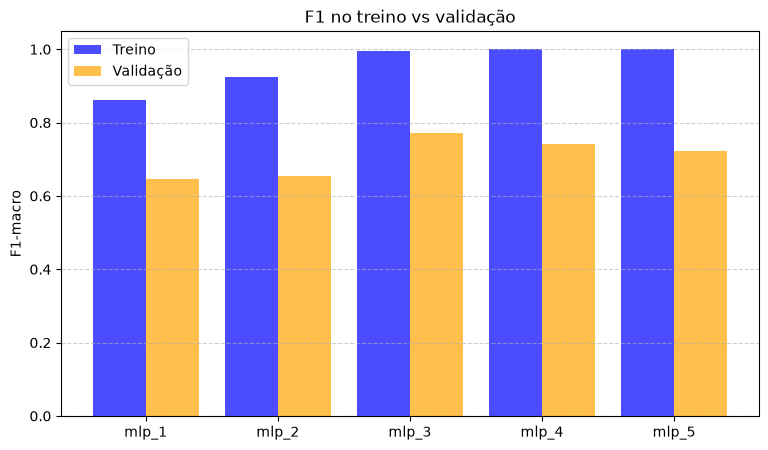

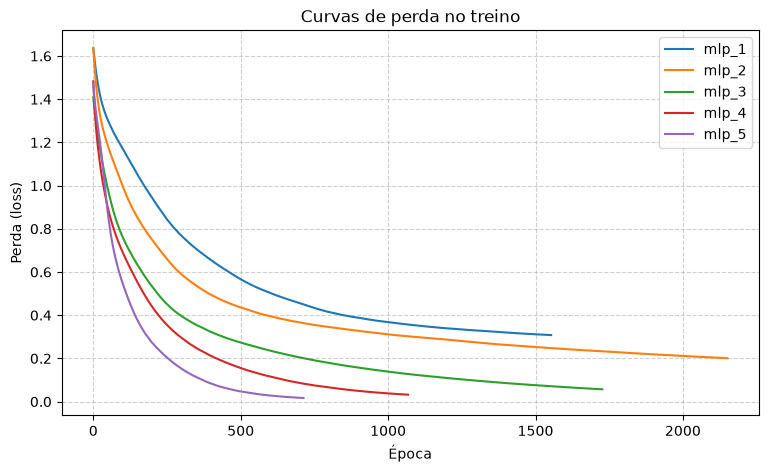

In [12]:
# F1 no treino vs F1 na validação
overfitting = {}
for nome, modelo in modelos.items():
    y_pred_treino = modelo.predict(x_treino)
    f1_treino = f1_score(y_treino, y_pred_treino, average='macro', zero_division=0)
    f1_val = resultados[nome]['f1']
    overfitting[nome] = {
        'f1_treino': f1_treino,
        'f1_validacao': f1_val,
        'diferenca': f1_treino - f1_val,
    }

df_overfitting = pd.DataFrame(overfitting).T.round(4)
print('Análise de overfitting')
print(df_overfitting)

# Gráfico: F1 treino vs validação
x = np.arange(len(df_overfitting))
plt.figure(figsize=(9, 5))
plt.bar(x - 0.2, df_overfitting['f1_treino'], width=0.4, label="Treino", color="blue", alpha=0.7)
plt.bar(x + 0.2, df_overfitting['f1_validacao'], width=0.4, label="Validação", color="orange", alpha=0.7)
plt.xticks(x, df_overfitting.index)
plt.ylabel("F1-macro")
plt.ylim(0, 1.05)
plt.title("F1 no treino vs validação")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.show()

# Curvas de perda de todos os modelos juntas
plt.figure(figsize=(9, 5))
for nome, modelo in modelos.items():
    plt.plot(modelo.loss_curve_, label=nome)
plt.xlabel("Época")
plt.ylabel("Perda (loss)")
plt.title("Curvas de perda no treino")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### 3.3 Interpretação dos resultados de overfitting

- Todos os modelos demonstraram overfitting, mas em graus diferentes. 
- Para o modelo 1 e 2, o F1 de treino não chegou a 1, isso indica que eles não conseguiram aprender o treino por completo. Logo a validação também é mais baixa. Aqui podemos identificar mais underfitting do que overfitting.
- O modelo 3 teve o melhor equilíbrio, os 32 neurônios indicam um ponto ideal para aprender o treino e não piorar na validação.
- Os modelos 4 e 5 gabaritaram o treino e demonstram pior desempenho na validação, com convergência bem mais rápida (700 no 5). 
- De modo geral, aumentando a capacidade da rede temos uma melhora na validação até o ponto do modelo 3, acima disso ele apenas se ajusta melhor ao treino.

## 4. Resultados dos experimentos

### 4.1 Resultados na Validação

-----
Tabela de resultados
       acuracia  precisao  recall      f1
mlp_3    0.8065    0.7722  0.7750  0.7728
mlp_4    0.8172    0.8614  0.7083  0.7424
mlp_5    0.8172    0.7475  0.7083  0.7231
mlp_2    0.7312    0.6781  0.6417  0.6556
mlp_1    0.7204    0.6697  0.6333  0.6469
-----


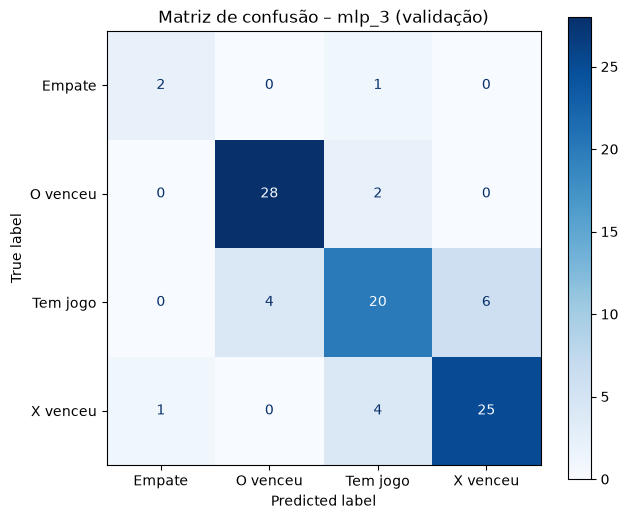

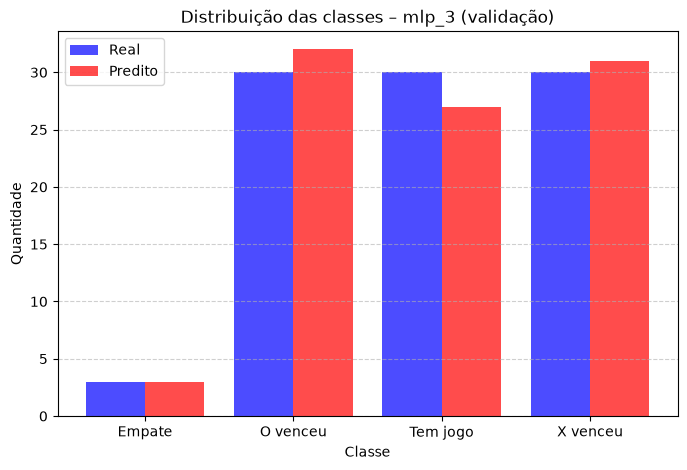

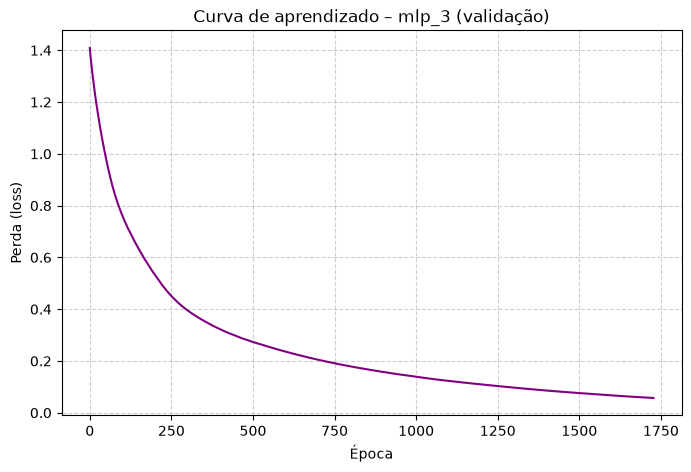

Relatório – mlp_3 (validação)
              precision    recall  f1-score   support

      Empate       0.67      0.67      0.67         3
    O venceu       0.88      0.93      0.90        30
    Tem jogo       0.74      0.67      0.70        30
    X venceu       0.81      0.83      0.82        30

    accuracy                           0.81        93
   macro avg       0.77      0.78      0.77        93
weighted avg       0.80      0.81      0.80        93

Camadas ocultas: (32,)
Camadas totais (entrada + ocultas + saída): 3
Camada 0 → 1: pesos (9, 32), bias (32,)
Camada 1 → 2: pesos (32, 4), bias (4,)


In [13]:
print("-----")
print('Tabela de resultados')
df = pd.DataFrame(resultados).T.round(4)
print(df.sort_values('f1', ascending=False))
print('-----')

melhor = df['f1'].idxmax()
graficos(melhor, y_validacao, predicoes[melhor], 'validação')


### 4.2 Gráfico comparativo

No gráfico comparativo podemos observar que o modelo 3 é muito mais homogênio em todas as métricas, com acurácia, precisão, recall e f1 próximos de 0,8.

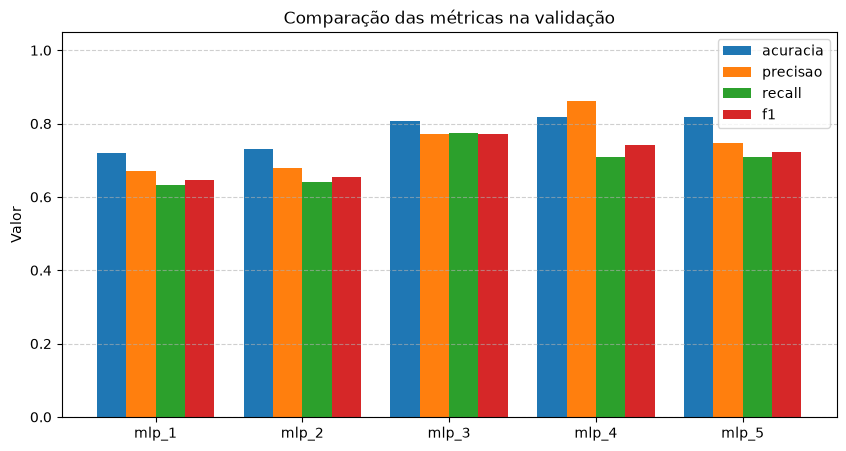

In [14]:
# Comparação das 4 métricas na validação para cada modelo
metricas = ['acuracia', 'precisao', 'recall', 'f1']
x = np.arange(len(df))
largura = 0.2

plt.figure(figsize=(10, 5))
for i, metrica in enumerate(metricas):
    plt.bar(x + (i - 1.5) * largura, df[metrica], width=largura, label=metrica)
plt.xticks(x, df.index)
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.title("Comparação das métricas na validação")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.show()

### 4.3 Avaliação no conjunto de teste

-----
Resultado final no teste – mlp_3
acuracia    0.7849
precisao    0.6803
recall      0.6833
f1          0.6771
dtype: float64
-----


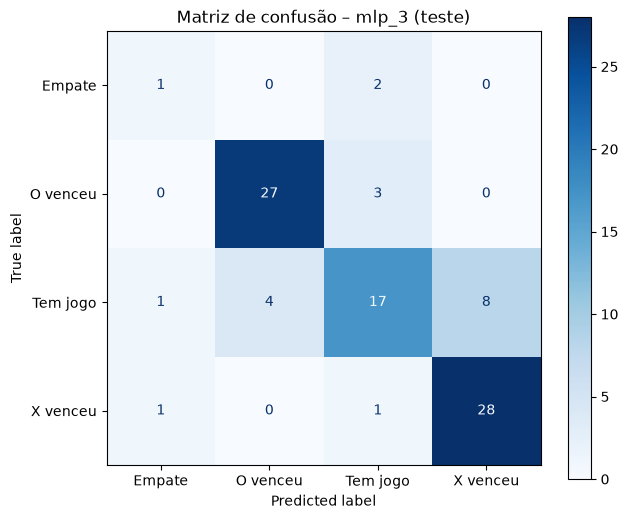

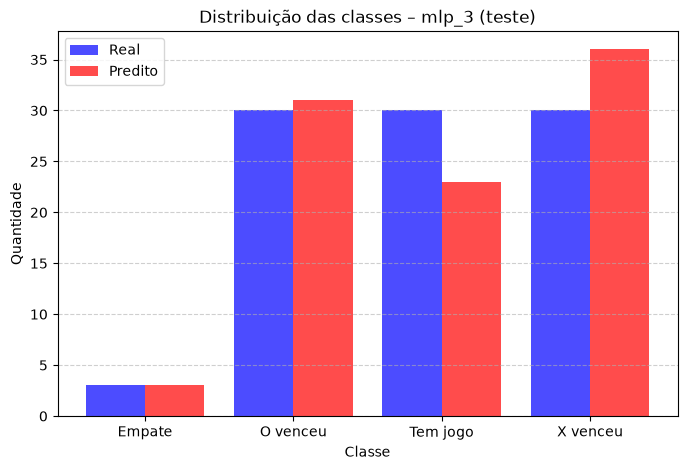

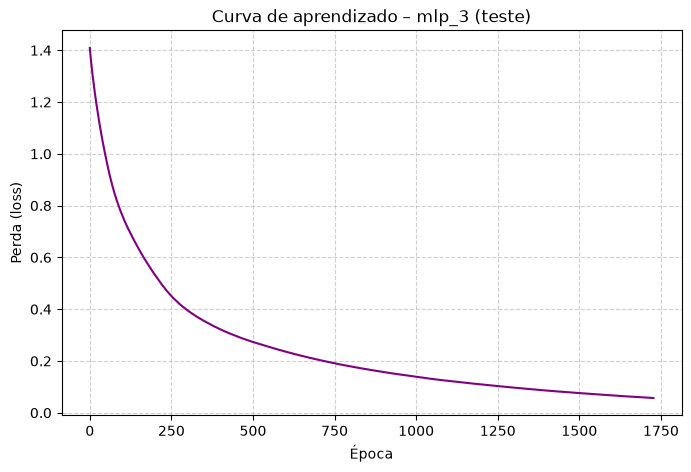

Relatório – mlp_3 (teste)
              precision    recall  f1-score   support

      Empate       0.33      0.33      0.33         3
    O venceu       0.87      0.90      0.89        30
    Tem jogo       0.74      0.57      0.64        30
    X venceu       0.78      0.93      0.85        30

    accuracy                           0.78        93
   macro avg       0.68      0.68      0.68        93
weighted avg       0.78      0.78      0.78        93

Camadas ocultas: (32,)
Camadas totais (entrada + ocultas + saída): 3
Camada 0 → 1: pesos (9, 32), bias (32,)
Camada 1 → 2: pesos (32, 4), bias (4,)


In [15]:
# Avaliação final no TESTE
modelo_final = modelos[melhor]
y_pred_teste = modelo_final.predict(x_teste)

resultado_teste = {
    'acuracia': accuracy_score(y_teste, y_pred_teste),
    'precisao': precision_score(y_teste, y_pred_teste, average='macro', zero_division=0),
    'recall':   recall_score(y_teste, y_pred_teste, average='macro', zero_division=0),
    'f1':       f1_score(y_teste, y_pred_teste, average='macro', zero_division=0),
}

print('-----')
print(f'Resultado final no teste – {melhor}')
print(pd.Series(resultado_teste).round(4))
print('-----')

graficos(melhor, y_teste, y_pred_teste, 'teste')

### 4.4 Análise dos resultados

Dado que o conjunto de dados é limitado quando se trata de empate, este resultado não foi tão satisfatório. O mesmo se nota no 'tem jogo', como ambos são status sem vencedor a rede tendeu a confundir e colocar o resultado em X ou O venceu.
A necessidade de fazer o oversampling nos empates para o treino pode influenciar na diferença entre o treino e validação. 
O aumento na quantidade de neurônios se mostrou eficaz até 32 neurônios, acima disso foi o overfitting se intensificou e nos casos abaixo se observou underfitting. 

## 5. Conclusão

O modelo 3 com 32 neurônios teve melhor resultado, com F1 macro do teste 68%, 78% de acurácia no teste e 81% na validação. Todos os modelos demonstraram melhor desempenho no treino, sendo os modelos 1 e 2 inferiores no desempenho do treino e da validação.